# Assignment 1 — Natural Language Processing

---

## A. Tokens, Types, Zipf's Law

We tokenize the WSJ corpus (`wsj_untokenized.txt`) using three methods:
1. **NLTK** — `nltk.word_tokenize()`
2. **spaCy** — `en_core_web_sm` model (tokenizer only)
3. **BERT** — `BertTokenizer` from HuggingFace (`bert-base-cased`)

Then we compute statistics, compare outputs, and analyse Zipf's law.

In [17]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import sys, os

import pandas as pd
import matplotlib.pyplot as plt

import nltk

# Add scripts/ to path so we can import our modules
sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

from part_a import (
    load_corpus, tokenize_nltk, tokenize_spacy, tokenize_bert,
    compute_statistics, pick_random_sentence, compare_tokenizers_on_sentence,
    top_types_covering_fraction, find_best_zipf_constant, plot_zipf,
)
from part_b import (
    load_treebank, preprocess_original, NgramLM, PREPROCESSING, MIN_COUNT,
)

# Download required NLTK data
nltk.download("punkt_tab", quiet=True)
nltk.download("treebank", quiet=True)

print("Setup complete.")

Setup complete.


In [18]:
# ── Load the WSJ corpus ──────────────────────────────────────────────────────
corpus_path = "wsj_untokenized.txt"
raw_text = load_corpus(corpus_path)
print(f"Corpus loaded: {len(raw_text):,} characters")

Corpus loaded: 500,996 characters


In [19]:
# ── Tokenize with all three methods ──────────────────────────────────────────
print("Tokenizing with NLTK...")
tokens_nltk = tokenize_nltk(raw_text)
print(f"  NLTK done: {len(tokens_nltk):,} tokens")

print("Tokenizing with spaCy...")
tokens_spacy = tokenize_spacy(raw_text)
print(f"  spaCy done: {len(tokens_spacy):,} tokens")

print("Tokenizing with BERT...")
tokens_bert = tokenize_bert(raw_text)
print(f"  BERT done: {len(tokens_bert):,} tokens")

Tokenizing with NLTK...
  NLTK done: 93,530 tokens
Tokenizing with spaCy...
  spaCy done: 95,925 tokens
Tokenizing with BERT...


Token indices sequence length is longer than the specified maximum sequence length for this model (112325 > 512). Running this sequence through the model will result in indexing errors


  BERT done: 112,325 tokens


### A.1 — Statistics Table

We compute for each tokenizer:
- **#tokens** — total number of tokens in the collection
- **#types** — number of distinct tokens (types)
- **TTR** — type-token ratio (types / tokens)
- **Hapax legomena** — types appearing exactly once
- **Hapax dislegomena** — types appearing exactly twice

In [20]:
# ── A.1: Statistics table ────────────────────────────────────────────────────
stats_nltk = compute_statistics(tokens_nltk)
stats_spacy = compute_statistics(tokens_spacy)
stats_bert = compute_statistics(tokens_bert)

df_stats = pd.DataFrame({
    "NLTK": {
        "#tokens": stats_nltk["tokens"],
        "#types": stats_nltk["types"],
        "TTR": round(stats_nltk["ttr"], 4),
        "Hapax legomena": stats_nltk["hapax_legomena"],
        "Hapax dislegomena": stats_nltk["hapax_dislegomena"],
    },
    "spaCy": {
        "#tokens": stats_spacy["tokens"],
        "#types": stats_spacy["types"],
        "TTR": round(stats_spacy["ttr"], 4),
        "Hapax legomena": stats_spacy["hapax_legomena"],
        "Hapax dislegomena": stats_spacy["hapax_dislegomena"],
    },
    "BERT": {
        "#tokens": stats_bert["tokens"],
        "#types": stats_bert["types"],
        "TTR": round(stats_bert["ttr"], 4),
        "Hapax legomena": stats_bert["hapax_legomena"],
        "Hapax dislegomena": stats_bert["hapax_dislegomena"],
    },
})

print("A.1 — Tokenization Statistics")
print("=" * 60)
df_stats

A.1 — Tokenization Statistics


,NLTK,spaCy,BERT
#tokens,93530.0000,95925.0000,112325.0000
#types,12000.0000,11522.0000,10266.0000
TTR,0.1283,0.1201,0.0914
Hapax legomena,6254.0000,5788.0000,3851.0000
Hapax dislegomena,1830.0000,1795.0000,1724.0000


### A.2 — Sentence-level Token Comparison

We pick a random sentence with at least 15 words and show the tokens produced by each method.

In [21]:
# ── A.2: Random sentence comparison ─────────────────────────────────────────
sentence = pick_random_sentence(raw_text, min_words=15, seed=42)
print("Selected sentence:")
print(f"  \"{sentence}\"")
print(f"  ({len(sentence.split())} words)\n")

comparison = compare_tokenizers_on_sentence(sentence)

for method, toks in comparison.items():
    print(f"{method} ({len(toks)} tokens):")
    print(f"  {toks}\n")

Selected sentence:
  "The scammers themselves were garden-variety low lifes, conspicuous consumers who wanted big houses, Mercedes cars, beautiful women, expensive clothes."
  (19 words)

NLTK (24 tokens):
  ['The', 'scammers', 'themselves', 'were', 'garden-variety', 'low', 'lifes', ',', 'conspicuous', 'consumers', 'who', 'wanted', 'big', 'houses', ',', 'Mercedes', 'cars', ',', 'beautiful', 'women', ',', 'expensive', 'clothes', '.']

spaCy (26 tokens):
  ['The', 'scammers', 'themselves', 'were', 'garden', '-', 'variety', 'low', 'lifes', ',', 'conspicuous', 'consumers', 'who', 'wanted', 'big', 'houses', ',', 'Mercedes', 'cars', ',', 'beautiful', 'women', ',', 'expensive', 'clothes', '.']

BERT (29 tokens):
  ['The', 's', '##cam', '##mers', 'themselves', 'were', 'garden', '-', 'variety', 'low', 'life', '##s', ',', 'conspicuous', 'consumers', 'who', 'wanted', 'big', 'houses', ',', 'Mercedes', 'cars', ',', 'beautiful', 'women', ',', 'expensive', 'clothes', '.']



### A.3 — Top Types Covering 30% of Tokens

For each tokenizer, we rank types by frequency and show those whose cumulative count reaches 30% of total tokens. We then check how many appear in all three methods.

In [22]:
# ── A.3: Top types covering 30% of tokens ───────────────────────────────────
top30_nltk = top_types_covering_fraction(stats_nltk["freq"], stats_nltk["tokens"], 0.30)
top30_spacy = top_types_covering_fraction(stats_spacy["freq"], stats_spacy["tokens"], 0.30)
top30_bert = top_types_covering_fraction(stats_bert["freq"], stats_bert["tokens"], 0.30)

print(f"NLTK:  {len(top30_nltk)} types cover 30% of tokens")
print(f"spaCy: {len(top30_spacy)} types cover 30% of tokens")
print(f"BERT:  {len(top30_bert)} types cover 30% of tokens")

# Build a combined table with all types from all methods
max_len = max(len(top30_nltk), len(top30_spacy), len(top30_bert))

def pad_list(lst, length):
    return lst + [("", "")] * (length - len(lst))

rows = []
for (w1, c1), (w2, c2), (w3, c3) in zip(
    pad_list(top30_nltk, max_len),
    pad_list(top30_spacy, max_len),
    pad_list(top30_bert, max_len),
):
    rows.append({
        "NLTK type": w1, "NLTK count": c1,
        "spaCy type": w2, "spaCy count": c2,
        "BERT type": w3, "BERT count": c3,
    })

df_top30 = pd.DataFrame(rows)
df_top30.index += 1
df_top30.index.name = "Rank"
df_top30

NLTK:  16 types cover 30% of tokens
spaCy: 16 types cover 30% of tokens
BERT:  14 types cover 30% of tokens


,NLTK type,NLTK count,spaCy type,spaCy count,BERT type,BERT count
Rank,,,,,,
1,",",4823,",",4823,.,6363
2,the,4041,the,4047,",",5026
3,.,3819,.,3760,',4117
4,of,2312,of,2313,the,4049
5,to,2157,to,2162,of,2314
6,a,1857,a,1869,to,2167
7,in,1563,in,1575,a,1927
8,and,1489,and,1495,-,1733
9,'',959,'',1372,in,1600


In [23]:
# Common types across all three methods
set_nltk = {w for w, _ in top30_nltk}
set_spacy = {w for w, _ in top30_spacy}
set_bert = {w for w, _ in top30_bert}

common = set_nltk & set_spacy & set_bert
print(f"\nTypes common to all 3 methods: {len(common)} out of "
      f"{len(set_nltk | set_spacy | set_bert)} unique types")
print(f"  {sorted(common)}")


Types common to all 3 methods: 11 out of 19 unique types
  [',', '.', 'The', 'a', 'and', 'for', 'in', 'of', 'that', 'the', 'to']


### A.4 — Zipf's Law

Zipf's Law states that: **P(rank r) = A / r**

We find the best constant A from {0.1, 0.2, ..., 1.0} by minimising the sum of squared errors between observed and predicted probabilities. We then plot observed vs predicted frequencies on a log-log scale.

We use the **NLTK tokenization** for this analysis (the choice of tokenizer does not materially affect Zipf's law).

Best Zipf constant A = 0.1
Plot saved to output/zipf_plot.png


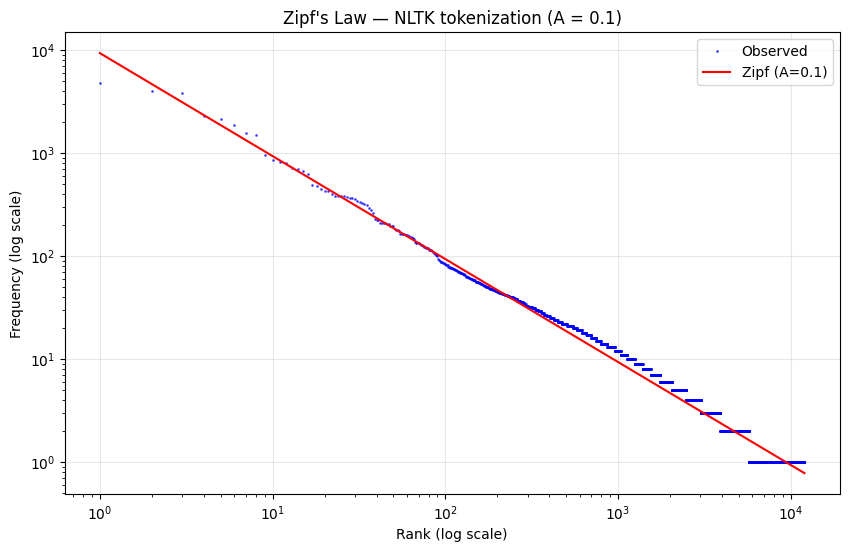

In [24]:
# ── A.4: Zipf's Law ─────────────────────────────────────────────────────────
best_a = find_best_zipf_constant(stats_nltk["freq"], stats_nltk["tokens"])
print(f"Best Zipf constant A = {best_a}")

fig = plot_zipf(
    stats_nltk["freq"],
    stats_nltk["tokens"],
    best_a,
    title=f"Zipf's Law — NLTK tokenization (A = {best_a})",
    save_path="output/zipf_plot.png",
)
print("Plot saved to output/zipf_plot.png")
plt.show()

---

## B. N-gram Language Models

We use the **NLTK treebank corpus** (199 pre-tokenized files from the Wall Street Journal).
- **Training:** first 170 files
- **Testing:** remaining 29 files
- Tokens appearing fewer than 3 times in training are replaced with `<UNK>`
- Each sentence is padded with `<BOS>` and `<EOS>` tokens
- We evaluate **bigram** and **trigram** models with **add-k smoothing** (k = 1, k = 0.01)
- Three preprocessing modes: **Original**, **Lowercase**, **Abstract digits** (digits replaced with `#`)

In [25]:
# ── Load treebank corpus ─────────────────────────────────────────────────────
train_sents_raw, test_sents_raw = load_treebank()
print(f"Training sentences: {len(train_sents_raw)}")
print(f"Test sentences:     {len(test_sents_raw)}")
print(f"\nExample (first sentence of training set):")
print(f"  {train_sents_raw[0]}")

Training sentences: 3509
Test sentences:     405

Example (first sentence of training set):
  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']


### B.1 — Perplexity Table

We train and evaluate 4 model configurations (bigram/trigram x k=1/k=0.01) under 3 preprocessing modes.

**Perplexity formula:** $\text{Perplexity} = e^{-\frac{1}{N}\sum_{i}^{N}\ln p(g_i)}$

where $g_i$ is a bigram/trigram and $N$ is the total number of bigrams/trigrams in the test set.

In [26]:
# ── B.1: Perplexity table ────────────────────────────────────────────────────
configs = [
    ("Bigrams (k=1)",    2, 1.0),
    ("Bigrams (k=0.01)", 2, 0.01),
    ("Trigrams (k=1)",   3, 1.0),
    ("Trigrams (k=0.01)", 3, 0.01),
]

preprocessing_modes = ["original", "lowercase", "abstract_digits"]
results = {}

for mode in preprocessing_modes:
    preprocess = PREPROCESSING[mode]
    train_sents = preprocess(train_sents_raw)
    test_sents = preprocess(test_sents_raw)

    for label, order, k in configs:
        model = NgramLM(order=order, k=k)
        model.fit(train_sents, min_count=MIN_COUNT)
        pp = model.perplexity(test_sents)
        results[(label, mode)] = round(pp, 2)
        print(f"  {label:<20s} | {mode:<16s} | perplexity = {pp:.2f}")

print("\nDone.")

  Bigrams (k=1)        | original         | perplexity = 383.66
  Bigrams (k=0.01)     | original         | perplexity = 137.83
  Trigrams (k=1)       | original         | perplexity = 1351.97
  Trigrams (k=0.01)    | original         | perplexity = 429.37
  Bigrams (k=1)        | lowercase        | perplexity = 384.11
  Bigrams (k=0.01)     | lowercase        | perplexity = 143.81
  Trigrams (k=1)       | lowercase        | perplexity = 1355.75
  Trigrams (k=0.01)    | lowercase        | perplexity = 443.44
  Bigrams (k=1)        | abstract_digits  | perplexity = 351.55
  Bigrams (k=0.01)     | abstract_digits  | perplexity = 125.40
  Trigrams (k=1)       | abstract_digits  | perplexity = 1250.89
  Trigrams (k=0.01)    | abstract_digits  | perplexity = 383.52

Done.


In [27]:
# ── B.1: Format as table ─────────────────────────────────────────────────────
col_labels = {"original": "Original text", "lowercase": "Lowercase", "abstract_digits": "Abstract digits"}
rows_data = {}
for label, _, _ in configs:
    rows_data[label] = {col_labels[m]: results[(label, m)] for m in preprocessing_modes}

df_perplexity = pd.DataFrame(rows_data).T
df_perplexity.index.name = "Language model"
print("B.1 — Perplexity Table")
print("=" * 60)
df_perplexity

B.1 — Perplexity Table


,Original text,Lowercase,Abstract digits
Language model,,,
Bigrams (k=1),383.66,384.11,351.55
Bigrams (k=0.01),137.83,143.81,125.40
Trigrams (k=1),1351.97,1355.75,1250.89
Trigrams (k=0.01),429.37,443.44,383.52


### B.2 — Sentence Generation

For each n-gram model (bigram and trigram, trained on the **original** text without preprocessing), we generate 3 sentences. Each sentence starts with `<BOS>` (and chosen start words) and ends at `<EOS>`. The next word is sampled proportionally to the n-gram probability. No `<UNK>` tokens appear in the output.

In [28]:
# ── B.2: Sentence generation ─────────────────────────────────────────────────
train_original = preprocess_original(train_sents_raw)

# Train bigram and trigram models on original text
bigram_model = NgramLM(order=2, k=0.01)
bigram_model.fit(train_original, min_count=MIN_COUNT)

trigram_model = NgramLM(order=3, k=0.01)
trigram_model.fit(train_original, min_count=MIN_COUNT)

# Start words for variety
start_options = [
    ["The"],
    ["Mr."],
    ["In"],
]

print("=" * 70)
print("BIGRAM MODEL — Generated sentences")
print("=" * 70)
for i, start in enumerate(start_options):
    sent = bigram_model.generate(start_words=start, max_len=30, seed=i)
    print(f"  {i+1}. {' '.join(sent)}")

print()
print("=" * 70)
print("TRIGRAM MODEL — Generated sentences")
print("=" * 70)
for i, start in enumerate(start_options):
    sent = trigram_model.generate(start_words=start, max_len=30, seed=i)
    print(f"  {i+1}. {' '.join(sent)}")

BIGRAM MODEL — Generated sentences
  1. The reason million *U* .
  2. Mr. Cannell revive private Volume features compete mechanical prison Australian 1999 regulation determined ran 'm economist met Mr. hearing sophisticated , '' caused trouble analysts Smith anyone *ICH*-2 What creditors equipment
  3. In the two Candela Carnival said 0 it bring individuals law in January by a sales withdraw town existing debts Stag 's .

TRIGRAM MODEL — Generated sentences
  1. The reason passage compromise States estimates claims protecting acquisition disgorge hazards substance encourage VOA poor intellectual-property Sherwood successor where reflects stores ads owners stepped metric directly Co. controls indicate suppliers van
  2. Mr. Coleman seemed preparation Southeast editorial curriculum line purchased Carlos 1988 right contract precisely 'd crime opinion Primerica town stood 1999 1976 file thus buy-out Orange concerns 1989-90 Parliament corn editors
  3. In the trillion 767 Brazil rider parti